In [1]:
import matplotlib.pyplot as plt

import numpy as np
import xpart as xp
import xtrack as xt

from xnlbd.analyse.normal_forms import *
from xnlbd.track import Henonmap
from xnlbd.visualise.orbits import get_orbit_points

In [2]:
# Lattice and beam parameters
alpha_x = 0.0
beta_x = 1.0
alpha_y = 0.0
beta_y = 1.0

Qx1 = 0.2071   # horizontal tune
Qy1 = 0.2071   # vertical tune

K2 = 1.0       # sextupole strength
K3 = 0.0       # octupole strength

nemitt_x = 1           # horizontal normalised emittance
nemitt_y = 0.0000001   # vertical normalised emittance (quasi-1D)

In [3]:
# Build Henon map element and xtrack line
henon1 = Henonmap(
    omega_x=2 * np.pi * Qx1,
    omega_y=2 * np.pi * Qy1,
    twiss_params=[alpha_x, beta_x, alpha_y, beta_y],
    dqx=0.0,
    dqy=0.0,
    dx=0.0,
    ddx=0.0,
    multipole_coeffs=[K2, K3],
    norm=False,
)

drift1 = xt.Drift(length=0.0)  # zero-length drift required for aperture check

line1 = xt.Line(
    elements=[drift1, henon1],
    element_names=["zero_len_drift", "henon"],
)
line1.particle_ref = xt.Particles(mass0=xp.PROTON_MASS_EV)
line1.twiss_default["method"] = "4d"
line1.config.XTRACK_GLOBAL_XY_LIMIT = 0.9
line1.build_tracker()

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [4]:
# Compute phase-space portrait in the horizontal plane (physical coords)
orbits1 = get_orbit_points(line1, element="henon", planes="H", num_pts=50)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


/mnt/hdd1/sterbini/IPAC2026_NL_matching/miniconda/lib/python3.13/site-packages/xtrack/particles/particles.py:1729: RuntimeWarning: invalid value encountered in divide
  pzeta = self.ptau / self.beta0


(np.float64(-0.9111532487781957),
 np.float64(0.9844933279188919),
 np.float64(-0.902679371649935),
 np.float64(0.9609229828800885))

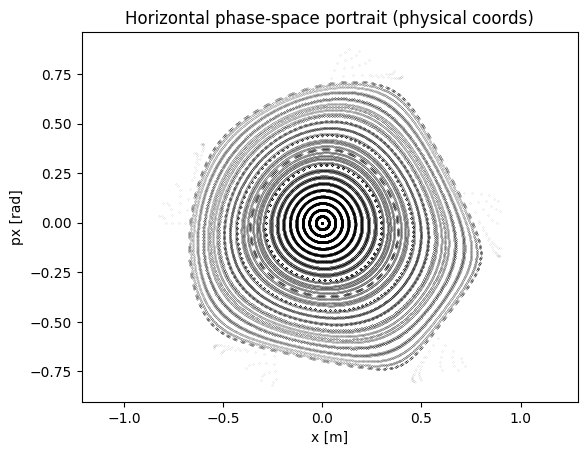

In [5]:
# Plot portrait in physical (x, px) coordinates
plt.figure()
plt.plot(
    orbits1["H_orbit_points"]["x"],
    orbits1["H_orbit_points"]["px"],
    color="black",
    marker=".",
    markersize=0.1,
    linestyle="None",
)
plt.xlabel("x [m]")
plt.ylabel("px [rad]")
plt.title("Horizontal phase-space portrait (physical coords)")
plt.axis("equal")

(np.float64(-940.6477683437734),
 np.float64(1016.3619051987529),
 np.float64(-931.8995872659948),
 np.float64(992.0285754437707))

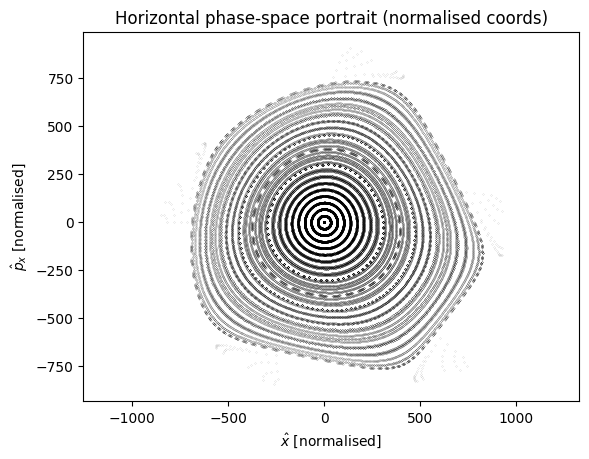

In [6]:
# Plot portrait in normalised (x_norm, px_norm) coordinates
plt.figure()
plt.plot(
    orbits1["H_orbit_points_norm"]["x_norm"],
    orbits1["H_orbit_points_norm"]["px_norm"],
    color="black",
    marker=".",
    markersize=0.1,
    linestyle="None",
)
plt.xlabel(r"$\hat{x}$ [normalised]")
plt.ylabel(r"$\hat{p}_x$ [normalised]")
plt.title("Horizontal phase-space portrait (normalised coords)")
plt.axis("equal")

In [7]:
# Compute the one-turn map and normal form via PolyLine4D
poly_line1 = PolyLine4D(
    line1,
    line1.particle_ref,
    max_ele_order=2,
    max_map_order=3,
    nemitt_x=nemitt_x,
    nemitt_y=nemitt_y,
)
poly_line1.calculate_one_turn_map()
poly_line1.calculate_normal_form(
    max_nf_order=8,
    res_space_dim=0,
    res_case=0,
)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Combining line elements: 100.00%
Combination of all line elements finished!


/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1056: ComplexWarning: Casting complex values to real discards the imaginary part
  x_norm = np.asarray((complex_norm[0] + complex_norm[1]) / 2.0, dtype=float)
/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1057: ComplexWarning: Casting complex values to real discards the imaginary part
  px_norm = np.asarray(
/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1060: ComplexWarning: Casting complex values to real discards the imaginary part
  y_norm = np.asarray((complex_norm[2] + complex_norm[3]) / 2.0, dtype=float)
/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1061: ComplexWarning: Casting complex values to real discards the imaginary part
  py_norm = np.asarray(


(np.float64(-0.9111532487781957),
 np.float64(0.9844933279188919),
 np.float64(-0.902679371649935),
 np.float64(0.9609229828800885))

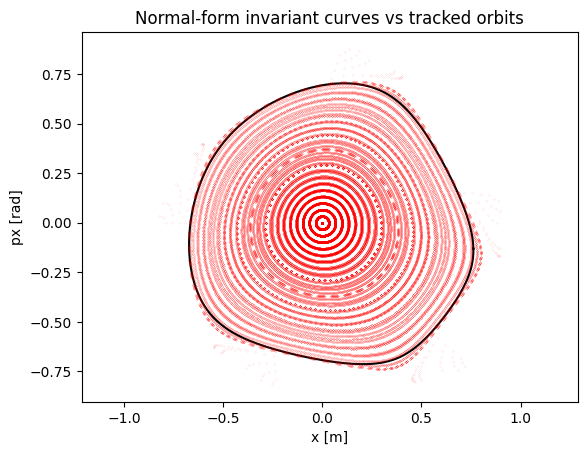

In [8]:
# Overlay normal-form invariant curves on top of tracked orbits
plt.figure()
for Ix in np.linspace(0, 0.25, 2):
    theta_x = np.linspace(0, 2 * np.pi, 200)
    # Complex normal-form coordinates for a circle of action Ix
    zeta_1 = np.sqrt(2 * Ix) * np.exp(1j * theta_x)
    zeta_1_conj = np.conjugate(zeta_1)
    zeta_2 = np.zeros_like(zeta_1)
    zeta_2_conj = np.zeros_like(zeta_1)
    # Map from normal-form to physical normalised coordinates
    aux = poly_line1.normal_form.nf_to_norm(zeta_1, zeta_1_conj, zeta_2, zeta_2_conj)
    plt.plot(
        np.real(aux[0]),
        np.real(aux[1]),
        color="black",
        linestyle="-",
        label="Normal form" if Ix == 0 else None,
    )

plt.plot(
    orbits1["H_orbit_points"]["x"],
    orbits1["H_orbit_points"]["px"],
    color="red",
    marker=".",
    markersize=0.1,
    linestyle="None",
    label="Tracked orbits",
)
plt.xlabel("x [m]")
plt.ylabel("px [rad]")
plt.title("Normal-form invariant curves vs tracked orbits")
plt.axis("equal")